<a href="https://colab.research.google.com/github/congtuan99/learning-data/blob/main/Jour_2_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Pandas


In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
df = sns.load_dataset("penguins")

In [60]:
df.groupby("species")["body_mass_g"].mean()

,body_mass_g
species,
Adelie,3700.662252
Chinstrap,3733.088235
Gentoo,5076.016260


In [61]:
df.groupby("species")["flipper_length_mm"].mean()

,flipper_length_mm
species,
Adelie,189.953642
Chinstrap,195.823529
Gentoo,217.186992


In [62]:

df[["body_mass_g","flipper_length_mm"]]

df.groupby("species")[["body_mass_g","flipper_length_mm"]].mean()


,body_mass_g,flipper_length_mm
species,,
Adelie,3700.662252,189.953642
Chinstrap,3733.088235,195.823529
Gentoo,5076.016260,217.186992


In [63]:

df.groupby("species")[["body_mass_g","flipper_length_mm"]].agg(["min","max","mean","std","count"])

body_mass_g                                         \
                  min     max         mean         std count   
species                                                        
Adelie         2850.0  4775.0  3700.662252  458.566126   151   
Chinstrap      2700.0  4800.0  3733.088235  384.335081    68   
Gentoo         3950.0  6300.0  5076.016260  504.116237   123   

          flipper_length_mm                                     
                        min    max        mean       std count  
species                                                         
Adelie                172.0  210.0  189.953642  6.539457   151  
Chinstrap             178.0  212.0  195.823529  7.131894    68  
Gentoo                203.0  231.0  217.186992  6.484976   123

In [64]:
df.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)



,body_mass_g
species,
Gentoo,5076.016260
Chinstrap,3733.088235
Adelie,3700.662252


In [65]:
df.groupby("species")["flipper_length_mm"].mean()

,flipper_length_mm
species,
Adelie,189.953642
Chinstrap,195.823529
Gentoo,217.186992


In [66]:
df.groupby("species")["body_mass_g"].agg(["mean","min","max"])

,mean,min,max
species,,,
Adelie,3700.662252,2850.0,4775.0
Chinstrap,3733.088235,2700.0,4800.0
Gentoo,5076.016260,3950.0,6300.0


In [67]:
df.groupby("island")["body_mass_g"].mean()

,body_mass_g
island,
Biscoe,4716.017964
Dream,3712.903226
Torgersen,3706.372549


commentaire: l'île Biscoe a une masse moyenne nettement supérieure à celle des deux autres , soit 4716 contre 3713 pour Dream et 3706 pour Torgersen.
Par ailleurs, les îles Dream et Torgersen ont des masses moyennes très proches. Alors pourquoi?
On pourrait prédire que l'espèce Gentoo qui présente principal à l'île Biscoe car les Gentoo ont une masse corporelle moyenne la plus élevé par rapport aux 2 autres.

In [68]:
df.groupby(["species","island"])["body_mass_g"].mean()


species    island   
Adelie     Biscoe       3709.659091
           Dream        3688.392857
           Torgersen    3706.372549
Chinstrap  Dream        3733.088235
Gentoo     Biscoe       5076.016260
Name: body_mass_g, dtype: float64

# Block 2: SQL

In [69]:
!pip install duckdb -q
import duckdb

In [70]:
duckdb.sql("select species, AVG(body_mass_g) from df group by species")


┌───────────┬────────────────────┐
│  species  │  avg(body_mass_g)  │
│  varchar  │       double       │
├───────────┼────────────────────┤
│ Adelie    │  3700.662251655629 │
│ Chinstrap │ 3733.0882352941176 │
│ Gentoo    │  5076.016260162602 │
└───────────┴────────────────────┘

In [71]:
duckdb.sql("select species, Count(species) as nb from df group by species")


┌───────────┬───────┐
│  species  │  nb   │
│  varchar  │ int64 │
├───────────┼───────┤
│ Adelie    │   152 │
│ Chinstrap │    68 │
│ Gentoo    │   124 │
└───────────┴───────┘

In [72]:
df["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [73]:
duckdb.sql("select species, AVG(body_mass_g), MAX(flipper_length_mm) from df group by species")

┌───────────┬────────────────────┬────────────────────────┐
│  species  │  avg(body_mass_g)  │ max(flipper_length_mm) │
│  varchar  │       double       │         double         │
├───────────┼────────────────────┼────────────────────────┤
│ Adelie    │  3700.662251655629 │                  210.0 │
│ Chinstrap │ 3733.0882352941176 │                  212.0 │
│ Gentoo    │  5076.016260162602 │                  231.0 │
└───────────┴────────────────────┴────────────────────────┘

In [74]:
df.groupby("species")[["body_mass_g","flipper_length_mm"]].agg({"body_mass_g":"mean","flipper_length_mm": "max"})



,body_mass_g,flipper_length_mm
species,,
Adelie,3700.662252,210.0
Chinstrap,3733.088235,212.0
Gentoo,5076.016260,231.0


In [75]:
duckdb.sql("select island, AVG(body_mass_g) from df group by island order by AVG(body_mass_g) DESC")

┌───────────┬────────────────────┐
│  island   │  avg(body_mass_g)  │
│  varchar  │       double       │
├───────────┼────────────────────┤
│ Biscoe    │  4716.017964071856 │
│ Dream     │ 3712.9032258064517 │
│ Torgersen │  3706.372549019608 │
└───────────┴────────────────────┘

In [76]:
df.groupby("island")["body_mass_g"].mean().sort_values(ascending=False)

,body_mass_g
island,
Biscoe,4716.017964
Dream,3712.903226
Torgersen,3706.372549


# Block 3: Visualisation

<Axes: xlabel='species'>

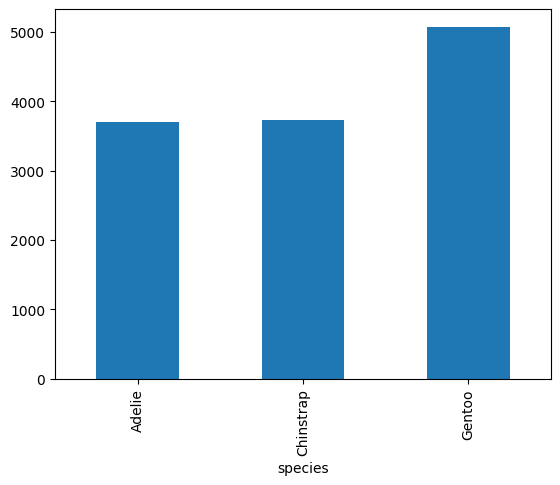

In [77]:

df.groupby("species")["body_mass_g"].mean().plot(kind="bar")

Text(0.5, 0, 'tên loài')

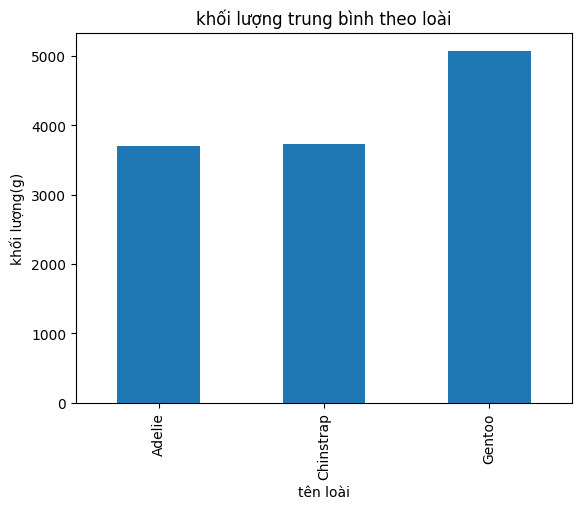

In [78]:
ax = df.groupby("species")["body_mass_g"].mean().plot(kind="bar",title="khối lượng trung bình theo loài")
ax.set_ylabel("khối lượng(g)")
ax.set_xlabel("tên loài")

<Axes: xlabel='species', ylabel='body_mass_g'>

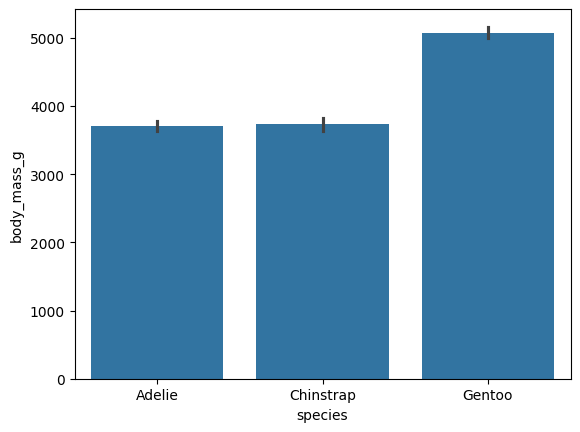

In [79]:

sns.barplot(data=df, x = "species", y = "body_mass_g")


Text(0, 0.5, 'longueur des nageoires moyenne')

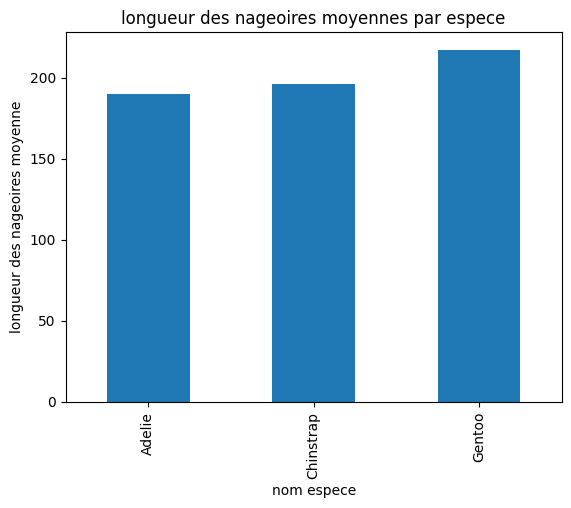

In [80]:

ax = df.groupby("species")["flipper_length_mm"].mean().plot(kind="bar",title="longueur des nageoires moyennes par espece")
ax.set_xlabel("nom espece")
ax.set_ylabel("longueur des nageoires moyenne")

<Axes: xlabel='species', ylabel='flipper_length_mm'>

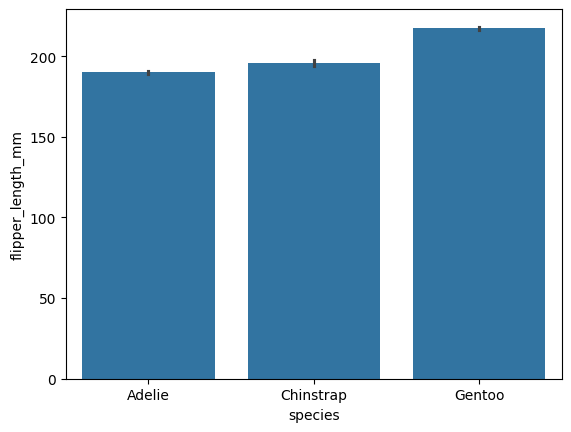

In [81]:

sns.barplot(data=df,x="species",y="flipper_length_mm")

<Axes: xlabel='island', ylabel='body_mass_g'>

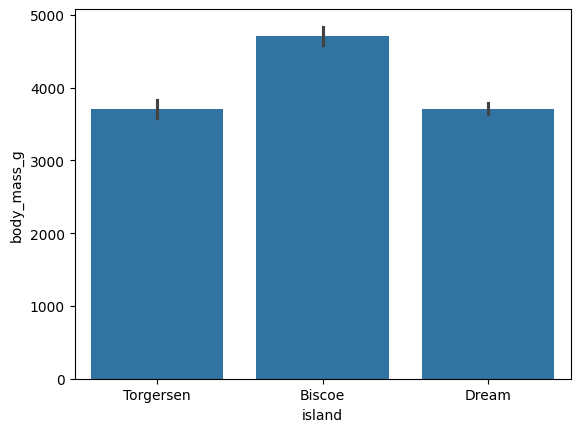

In [82]:
sns.barplot(data=df, x = "island", y="body_mass_g")

Text(0, 0.5, 'la masse moyenne')

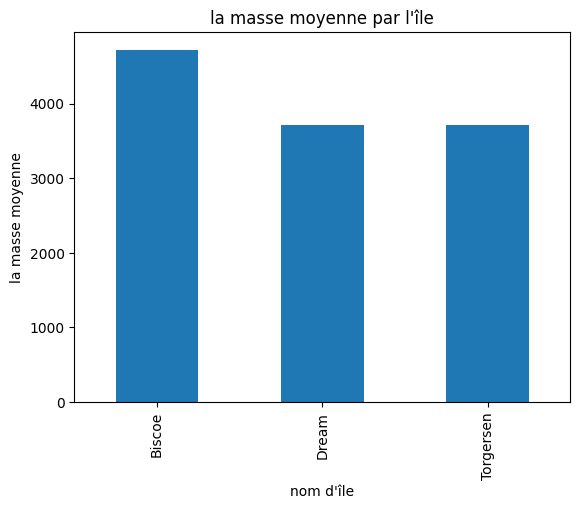

In [83]:
ax = df.groupby("island")["body_mass_g"].mean().plot(kind="bar",title="la masse moyenne par l'île")
ax.set_xlabel("nom d'île")
ax.set_ylabel("la masse moyenne")

<Axes: xlabel='island', ylabel='body_mass_g'>

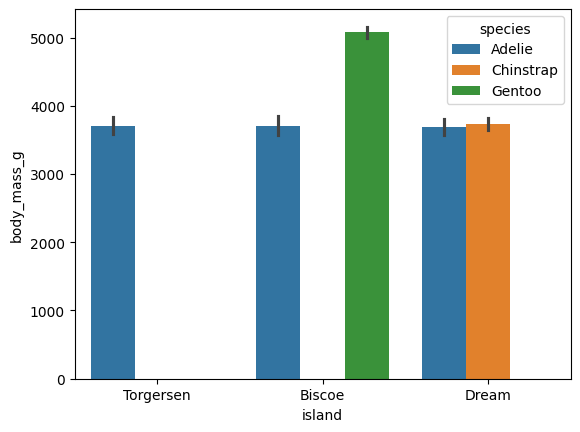

In [84]:
sns.barplot(data=df,x="island", y="body_mass_g", hue="species")

# COMMENTAIRE:
La figure confirme le résultat précédent: l'île Biscoe a une masse nettement supérieure à celle des deux autres. Cela s'explique par les Gentoo, qui ont la masse corporelle moyenne la plus élevée que l'on ne trouve que sur l'île Biscoe. Ils tirent donc la moyenne de cette île vers le haut.
En revanche, si l'on compare les trois îles pour une même espèce, la masse est à peu près équivalente. Il s'agit donc un facteur de confusion lié à la composition en espèce de chaque île.
Ce n'est donc pas l'île en elle-même qui explique la différence.